# Loan Default Prediction

In [1]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

c:\Users\bdion\Downloads\DSC180B\DSC180B\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Process Data

In [2]:
# Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter consumers with no transaction or balance information
consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [3]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 8
- New features: 8
- Unchanged feature creation functions: 0 (using cached results)

Executing features...
- Running average_transaction_amount...
- Running net_monthly_cash_flow...
- Running average_account_balance...
- Running time_based_average_transaction_amounts...
- Running descriptive_stats_by_category...
- Running outflow_stats...
- Running outflow_over_time_fix...
- Running balance_over_time...

Total Created Features:  266


## 2 Split Data

In [4]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7591
No validation set created.
Test set size: 2531


## 3. All Model Performances

In [5]:
summary_table = evaluate_feature_model_combinations(train_df, test_df, all_feature_columns)

Evaluating: Feature Selection = all_features, Model = xgboost
Evaluating: Feature Selection = all_features, Model = gradient_boosting
Evaluating: Feature Selection = all_features, Model = random_forest
Evaluating: Feature Selection = all_features, Model = logistic
Evaluating: Feature Selection = mutual_info, Model = xgboost
Evaluating: Feature Selection = mutual_info, Model = gradient_boosting
Evaluating: Feature Selection = mutual_info, Model = random_forest
Evaluating: Feature Selection = mutual_info, Model = logistic
Evaluating: Feature Selection = random_forest, Model = xgboost
Evaluating: Feature Selection = random_forest, Model = gradient_boosting
Evaluating: Feature Selection = random_forest, Model = random_forest
Evaluating: Feature Selection = random_forest, Model = logistic
Evaluating: Feature Selection = xgboost, Model = xgboost
Evaluating: Feature Selection = xgboost, Model = gradient_boosting
Evaluating: Feature Selection = xgboost, Model = random_forest
Evaluating: Featur

In [6]:
summary_table

,Feature Selection,Model,Test Accuracy,Test Balanced Accuracy,Test ROC AUC
0,all_features,xgboost,0.78,0.72,0.80
1,all_features,gradient_boosting,0.92,0.52,0.81
2,all_features,random_forest,0.92,0.52,0.78
3,all_features,logistic,0.69,0.69,0.73
4,mutual_info,xgboost,0.76,0.71,0.80
5,mutual_info,gradient_boosting,0.92,0.53,0.80
6,mutual_info,random_forest,0.92,0.52,0.77
7,mutual_info,logistic,0.64,0.70,0.73
8,random_forest,xgboost,0.76,0.73,0.80
9,random_forest,gradient_boosting,0.92,0.53,0.81


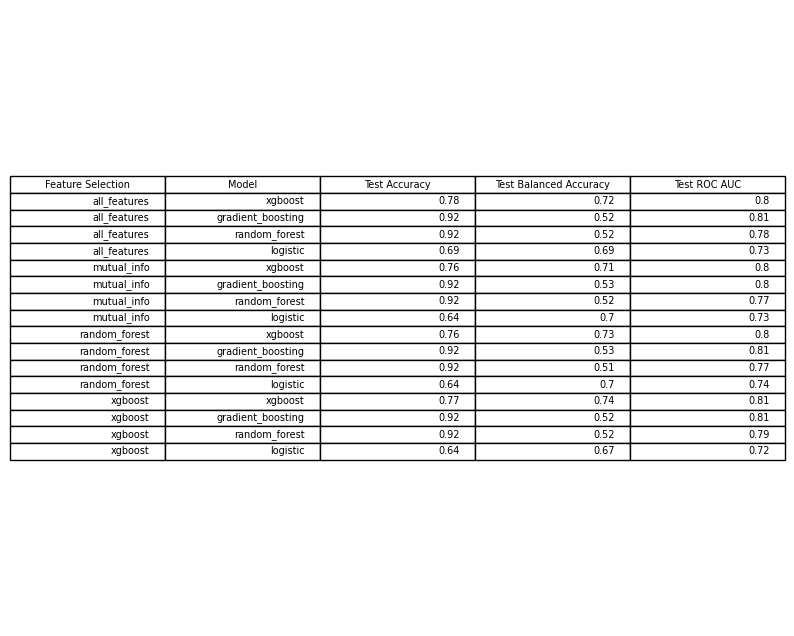

In [7]:
# Set up the matplotlib figure and axis
fig, ax = plt.subplots(figsize=(len(summary_table.columns) * 2, len(summary_table) * 0.5))
ax.axis('tight')
ax.axis('off')

# Create the table plot from the DataFrame
table = ax.table(cellText=summary_table.values, colLabels=summary_table.columns, loc='center')
 
# Save the figure as an image file
plt.show()

## 4. Individual Model Training

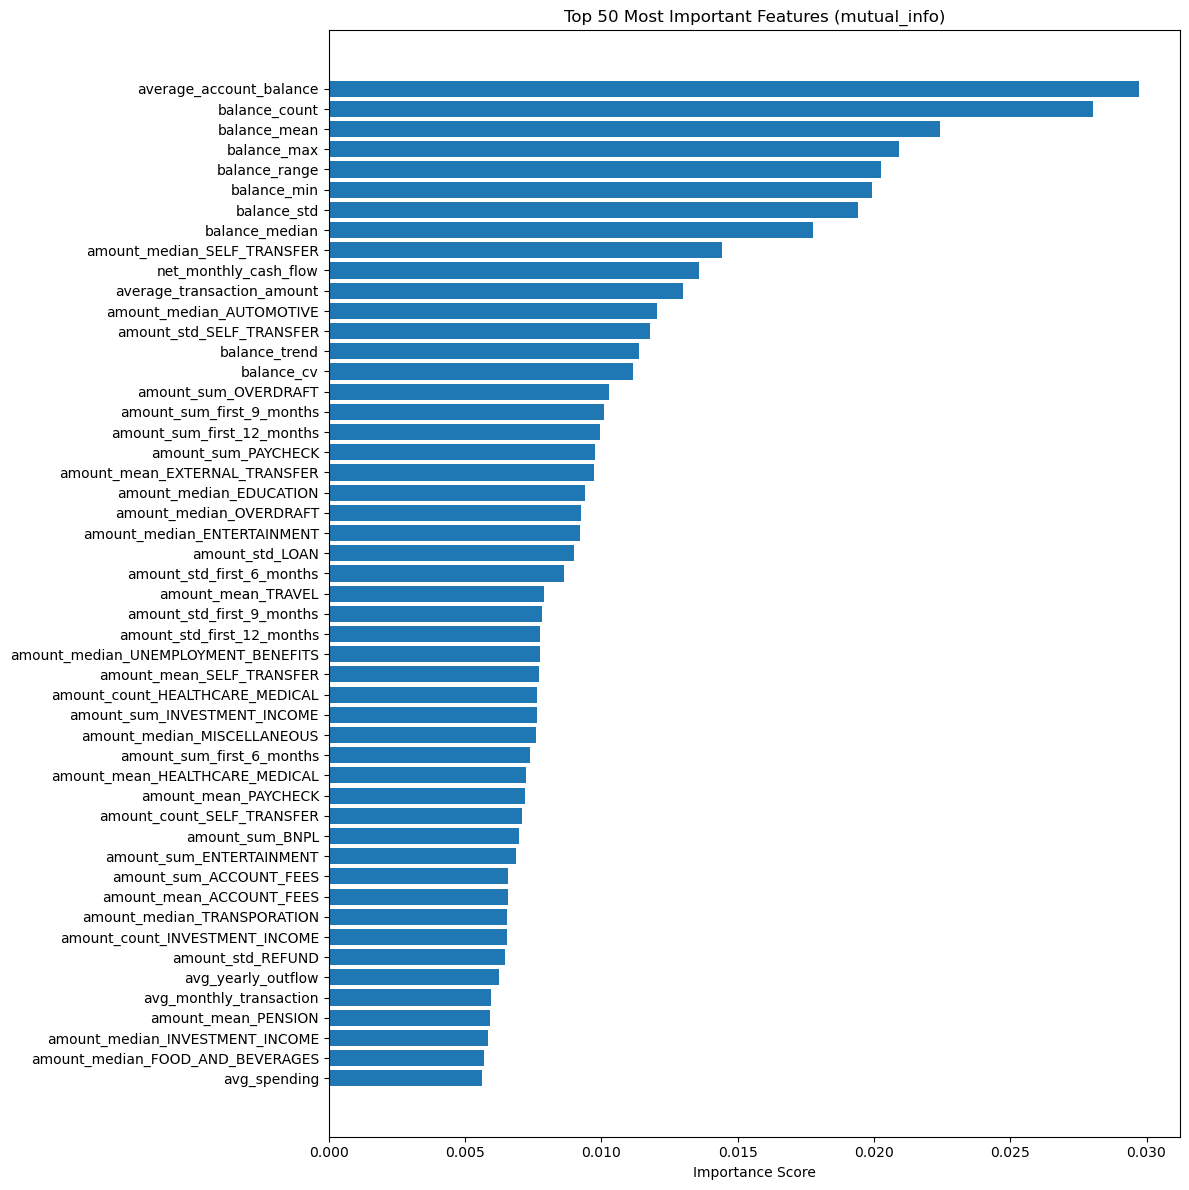

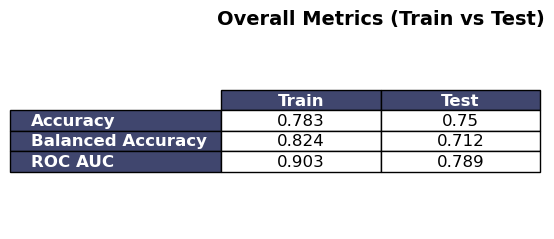


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.984765  0.773835  0.866651  6933.000000  0.962801  0.756664  0.847376  2326.000000
1.0           0.268315  0.873860  0.410568   658.000000  0.194879  0.668293  0.301762   205.000000
accuracy      0.782506  0.782506  0.782506     0.782506  0.749506  0.749506  0.749506     0.749506
macro avg     0.626540  0.823848  0.638609  7591.000000  0.578840  0.712478  0.574569  2531.000000
weighted avg  0.922662  0.782506  0.827117  7591.000000  0.900603  0.749506  0.803184  2531.000000


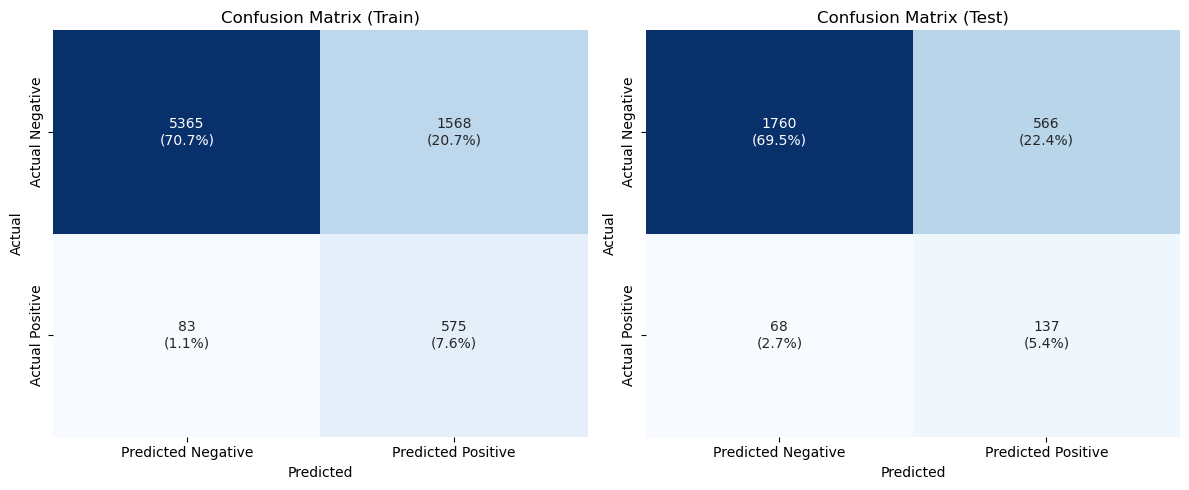

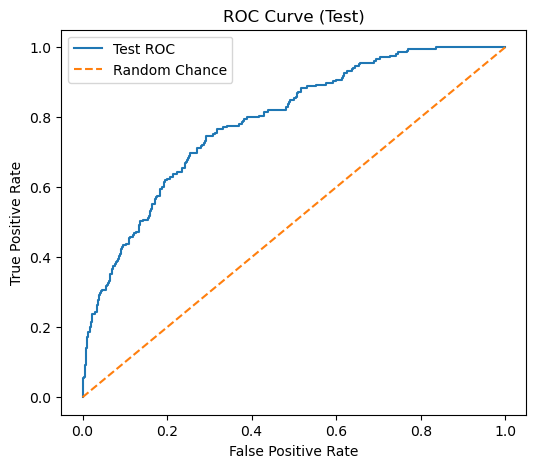

In [8]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

# Initialize and train model with all features
X_train, X_train_scaled, model, scaler = train_model(train_df, feature_columns, "xgboost")
X_test, X_test_scaled, y_test, y_pred_test, results = predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)

## 5. SHAP

- Most impactful features for the model overall (according to SHAP):

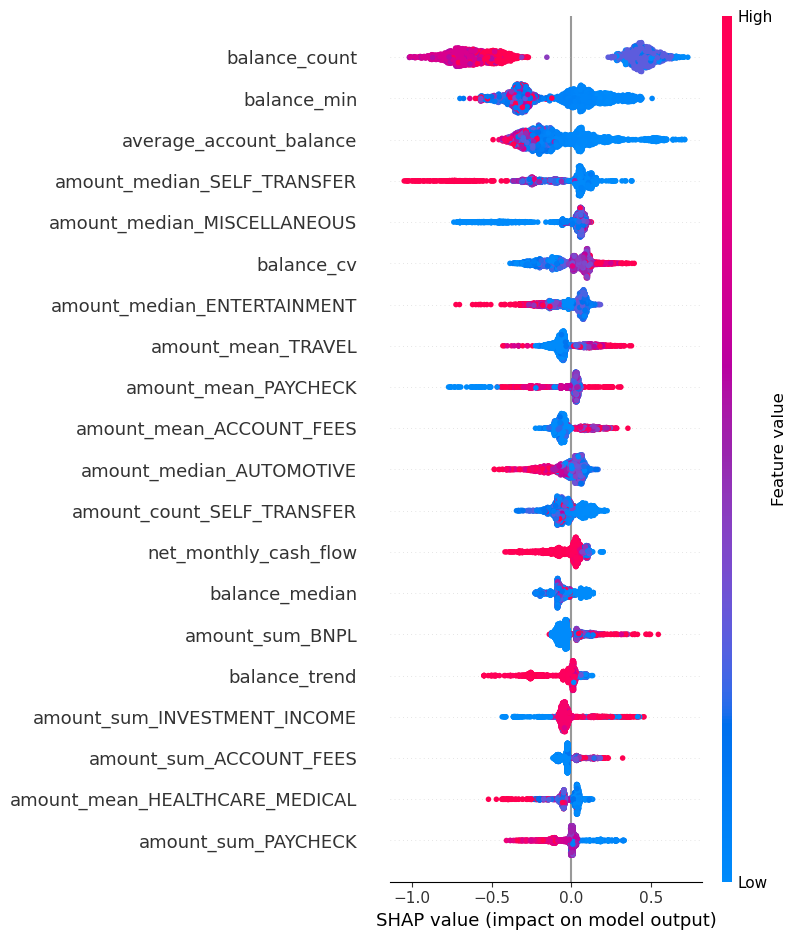

In [9]:
scaled_feats, explainer, shap_values = shap_plots(model, X_test, X_test_scaled)

- Waterfall plot for an individual person:
    - Person here was predicted as not defaulting

In [10]:
y_pred_test[0]

0

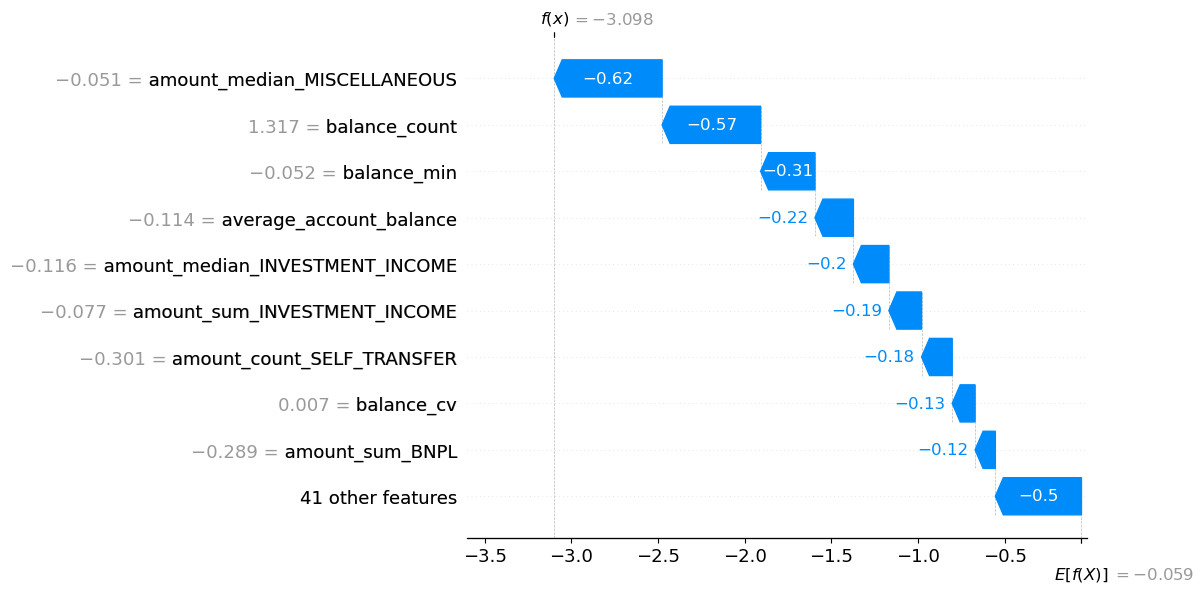

In [11]:
shap.plots.waterfall(shap_values[0])

- Reason codes for default:

In [12]:
scaled_feats['y_true'] = y_test.values
scaled_feats['y_pred'] = y_pred_test

shap_values = explainer(scaled_feats.drop(columns=['y_true', 'y_pred']))

shap_df = pd.DataFrame(shap_values.values, columns=scaled_feats.drop(columns=['y_true', 'y_pred']).columns)

mask = scaled_feats['y_pred'] == 1
shap_df_pred_default = shap_df[mask].reset_index(drop=True)

def get_top_feature_names(shap_row, feature_names, top_n=3):
    top_indices = np.argsort(shap_row)[::-1][:top_n]  
    return [feature_names[i] for i in top_indices]  

top_features_pred_default = shap_df_pred_default.apply(
    lambda row: get_top_feature_names(row, shap_df.columns), axis=1
)

top_features_df = pd.DataFrame(top_features_pred_default.tolist(), columns=['Feature_1', 'Feature_2', 'Feature_3'])
top_features_df

,Feature_1,Feature_2,Feature_3
0,balance_count,amount_sum_BNPL,balance_min
1,balance_count,average_account_balance,amount_mean_EXTERNAL_TRANSFER
2,balance_count,amount_mean_EXTERNAL_TRANSFER,balance_min
3,amount_sum_OVERDRAFT,amount_median_SELF_TRANSFER,average_account_balance
4,balance_count,amount_sum_INVESTMENT_INCOME,amount_mean_PAYCHECK
...,...,...,...
698,balance_count,balance_min,balance_cv
699,balance_count,balance_min,avg_yearly_outflow
700,balance_count,amount_mean_TRAVEL,amount_mean_ACCOUNT_FEES
701,amount_mean_SELF_TRANSFER,amount_sum_PAYCHECK,amount_sum_OVERDRAFT


In [28]:
reasons = top_features_pred_default.explode().value_counts().reset_index()
reasons.rename(columns={'index':'Reason'}, inplace=True)

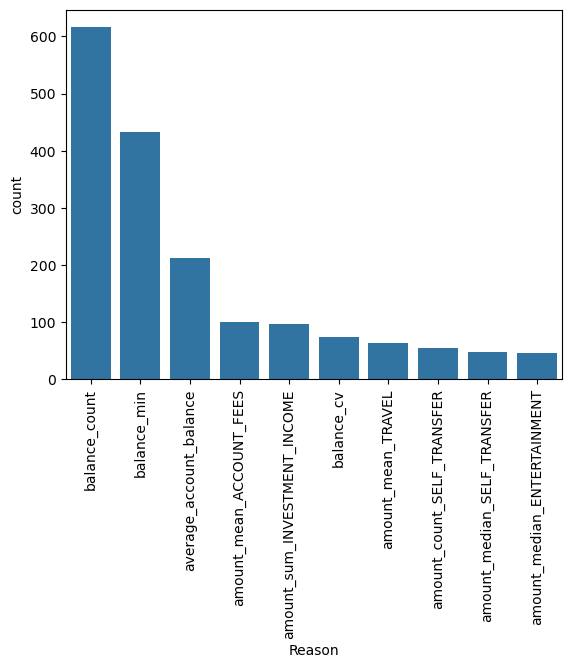

In [30]:
sns.barplot(reasons[:10], x='Reason', y='count');
plt.xticks(rotation=90);
plt.show();